In [2]:
# Run this once to ensure packages are installed, then you can ignore it
!python -m pip install tensorflow numpy matplotlib

Defaulting to user installation because normal site-packages is not writeable


### 1: Imports and Data Loading

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

print("Loading and preparing data...")
(x_train, _), (x_test, _) = tf.keras.datasets.mnist.load_data()
 
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.
 
x_train = np.reshape(x_train, (len(x_train), 28, 28, 1))
x_test = np.reshape(x_test, (len(x_test), 28, 28, 1))
print("Data ready! Shape:", x_train.shape)



Loading and preparing data...
Data ready! Shape: (60000, 28, 28, 1)


### 2: Building the Model

In [5]:
input_img = layers.Input(shape=(28, 28, 1))

# --- Encoder ---
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
x = layers.MaxPooling2D((2, 2), padding='same')(x)
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
encoded = layers.MaxPooling2D((2, 2), padding='same')(x)

# --- Decoder ---
x = layers.Conv2DTranspose(32, (3, 3), strides=2, activation='relu', padding='same')(encoded)
x = layers.Conv2DTranspose(32, (3, 3), strides=2, activation='relu', padding='same')(x)
decoded = layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

autoencoder = models.Model(input_img, decoded)
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

autoencoder.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 14, 14, 32)     │         9,248 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_3              │ (None, 28, 28, 32)     │         9,248 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,353 (110.75 KB)

 Trainable params: 28,353 (110.75 KB)

 Non-trainable params: 0 (0.00 B)

### 3: Training

In [6]:
print("Starting training...")
history = autoencoder.fit(
    x_train_noisy, x_train, # Train using NOISY inputs to target CLEAN outputs
    epochs=10, 
    batch_size=128,
    shuffle=True,
    validation_data=(x_test_noisy, x_test)
)

Starting training...
Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 15s 28ms/step - loss: 0.1927 - val_loss: 0.1202
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 65s 138ms/step - loss: 0.1157 - val_loss: 0.1114
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 59s 88ms/step - loss: 0.1105 - val_loss: 0.1079
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 35s 76ms/step - loss: 0.1079 - val_loss: 0.1060
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 48s 102ms/step - loss: 0.1062 - val_loss: 0.1046
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 63s 134ms/step - loss: 0.1049 - val_loss: 0.1034
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 80s 129ms/step - loss: 0.1038 - val_loss: 0.1025
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 63s 133ms/step - loss: 0.1029 - val_loss: 0.1018
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 62s 131ms/step - loss: 0.1021 - val_loss: 0.1008
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 17s 35ms/step - loss: 0.1014 - val_loss: 0.1006


### 6: Testing and Visualization

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


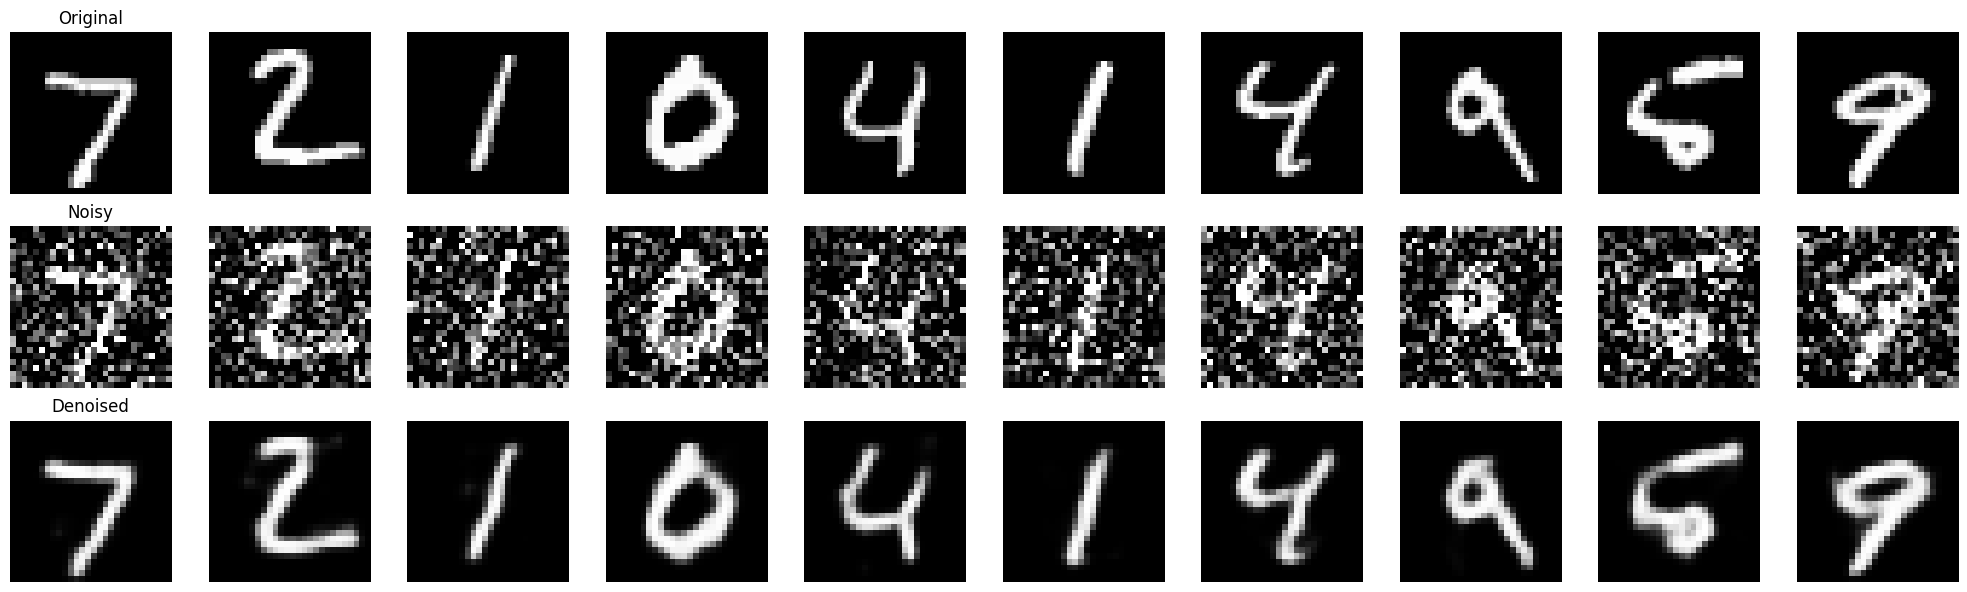

In [7]:
# Generate predictions
decoded_imgs = autoencoder.predict(x_test_noisy)

n = 10  # How many digits we will display
plt.figure(figsize=(20, 6))
for i in range(n):
    # Original
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    plt.title("Original" if i == 0 else "")
    plt.axis("off")

    # Noisy Input
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(x_test_noisy[i].reshape(28, 28), cmap='gray')
    plt.title("Noisy" if i == 0 else "")
    plt.axis("off")

    # Denoised Output
    ax = plt.subplot(3, n, i + 1 + 2 * n)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap='gray')
    plt.title("Denoised" if i == 0 else "")
    plt.axis("off")

plt.tight_layout()
plt.show()